In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer


from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV


from warnings import filterwarnings
filterwarnings('ignore')

In [ ]:
df = pd.read_csv("flightFare.csv")

In [ ]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


This dataset contains the following columns:

| Column Name     | Description                                                                                             |
| :-------------- | :------------------------------------------------------------------------------------------------------ |
| **Airline**     | Type of airline (e.g., IndiGo, Jet Airways, Air India).                                                 |
| **Date_of_Journey** | Date on which the passenger's journey will start.                                                     |
| **Source**      | Starting point of the journey.                                                                          |
| **Destination** | Destination of the journey.                                                                             |
| **Route**       | The flight path from source to destination, including layovers.                                         |
| **Arrival_Time**| Time when the passenger will reach their destination.                                                   |
| **Duration**    | Total time the flight will take to complete its journey.                                                |
| **Total_Stops** | Number of stops the flight will make during the journey.                                                |
| **Additional_Info** | Information about services like in-flight meals, baggage, etc.                                        |
| **Price**       | The price of the flight for the complete journey, including all expenses before onboarding (Target variable).

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [ ]:
df.shape

(10683, 11)

In [ ]:

df.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,1
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,1
Additional_Info,0


In [ ]:
df.dropna(inplace=True)
df.shape

(10682, 11)

In [ ]:
df.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662


## Data Cleaning & Feature Engineering

- **Date & Time Processing:**  
  Extracted day, month, hour, and minute from date/time columns and removed original columns to make the data model-friendly.

- **Total Stops Encoding:**  
  Converted `Total_Stops` into numerical values (0, 1, 2, etc.) to reflect its ordinal nature.

- **Additional_Info Handling:**  
  Standardized values and grouped rare categories into "Other" to reduce noise and avoid overfitting.

- **Route Feature Removal:**  
  Dropped the `Route` column due to high cardinality and redundancy with existing features.

### Preprocessing Plan

- **Categorical Features:**  
  Apply one-hot encoding to `Airline`, `Source`, `Destination`, and `Additional_Info`.

- **Numerical Features:**  
  Apply scaling (e.g., StandardScaler) for linear models, while tree-based models do not require scaling.

#### Data Cleaning (Datetime format)

In [ ]:
# Date of Journey
df['journey_month'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y', errors='coerce').dt.month
df['journey_day'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y', errors='coerce').dt.day
df.drop("Date_of_Journey", axis=1, inplace=True)

In [ ]:
# Dep_Time
df['Dep_hour'] = pd.to_datetime(df['Dep_Time']).dt.hour
df['Dep_min'] = pd.to_datetime(df['Dep_Time']).dt.minute
df.drop('Dep_Time', axis=1, inplace=True)

In [ ]:
# Arrival Time
df['Arrival_Time'] = df['Arrival_Time'].str.split(" ").str[0]
df['Arrival_hour'] = pd.to_datetime(df['Arrival_Time']).dt.hour
df['Arrival_min'] = pd.to_datetime(df['Arrival_Time']).dt.minute
df.drop('Arrival_Time', axis=1, inplace=True)

In [ ]:
# Extract hours and minutes directly from DURATION
df['Duration_hour'] = df['Duration'].str.extract(r'(\d+)h').fillna(0).astype(int)
df['Duration_min'] = df['Duration'].str.extract(r'(\d+)m').fillna(0).astype(int)

# Drop original column
df.drop('Duration', axis=1, inplace=True)

In [ ]:
df.head(2)

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,journey_month,journey_day,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hour,Duration_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,3,24,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,5,1,5,50,13,15,7,25


In [ ]:
df.Total_Stops.value_counts()

,count
Total_Stops,
1 stop,5625
non-stop,3491
2 stops,1520
3 stops,45
4 stops,1


In [ ]:
df["Total_Stops"] = df["Total_Stops"].map({
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
})

In [ ]:
df.head(2)

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,journey_month,journey_day,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hour,Duration_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,0,No info,3897,3,24,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2,No info,7662,5,1,5,50,13,15,7,25


In [ ]:
df.Additional_Info.value_counts()

,count
Additional_Info,
No info,8344
In-flight meal not included,1982
No check-in baggage included,320
1 Long layover,19
Change airports,7
Business class,4
No Info,3
1 Short layover,1
Red-eye flight,1


In [ ]:
# clean the no info value because it has the duplicates
df['Additional_Info'] = df['Additional_Info'].replace('No Info', 'No info')

In [ ]:
# handling the rare value
counts = df.Additional_Info.value_counts()
rare = counts[counts < 10].index
df['Additional_Info'] = df['Additional_Info'].replace(rare, 'Other')

In [ ]:
df.groupby('Additional_Info')['Price'].mean()

,Price
Additional_Info,
1 Long layover,22109.631579
In-flight meal not included,9471.834511
No check-in baggage included,3645.156250
No info,9141.125075
Other,29210.428571


In [ ]:
# Droping the Route as it is not needed
df.drop('Route', axis=1, inplace=True)

In [ ]:
df.head(2)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,journey_month,journey_day,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hour,Duration_min
0,IndiGo,Banglore,New Delhi,0,No info,3897,3,24,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2,No info,7662,5,1,5,50,13,15,7,25


## EDA

#### 1.Target Value

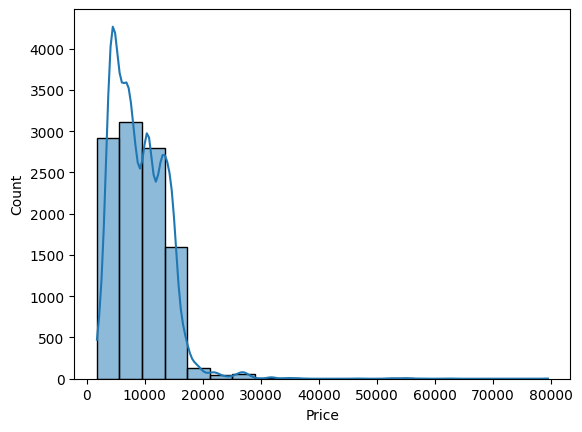

In [ ]:
# Target Value
sns.histplot(
    data = df,
    x = 'Price',
    kde=True,
    bins=20
)
plt.show()

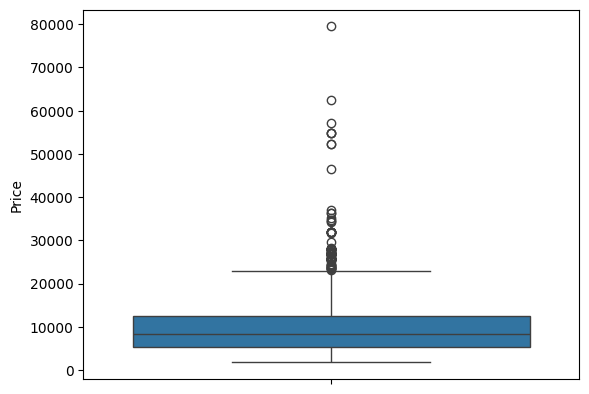

In [ ]:
sns.boxplot(data = df, y = 'Price')
plt.show()

## Price Distribution Analysis: Key Insights

- The price distribution is right-skewed, with most flights priced on the lower side.
- Most ticket prices fall within the ₹0–₹35,000 range.
- Higher prices show greater variability.
- A few extreme high-price outliers (up to ₹80,000) are present and may affect model performance.

#### 2.Categorical vs Price

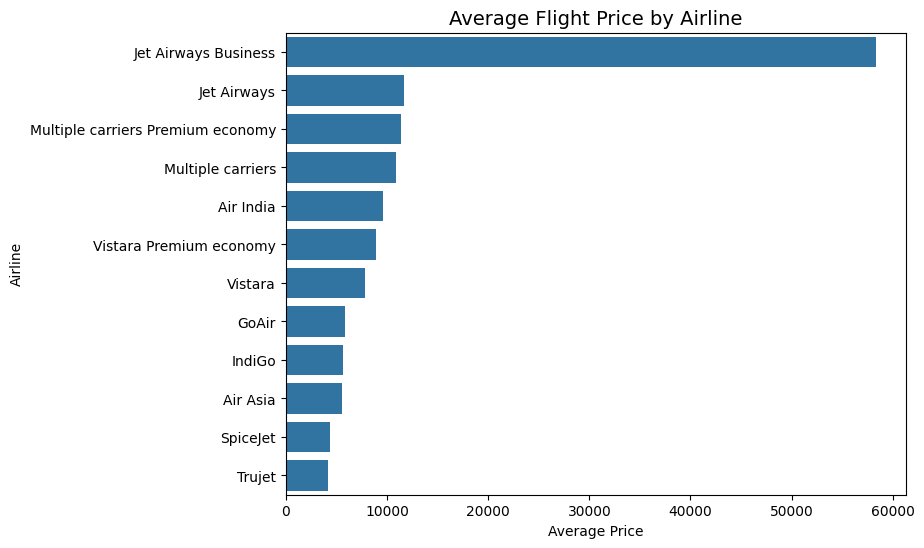

In [ ]:
# Airline Vs Price

df_grouped = df.groupby('Airline')['Price'].mean().reset_index().sort_values(by='Price',ascending=False)

plt.figure(figsize=(8,6))

sns.barplot(
    data=df_grouped,
    y='Airline',
    x='Price',
)

plt.title('Average Flight Price by Airline', fontsize=14)
plt.xlabel('Average Price')
plt.ylabel('Airline')

plt.show()

## Airline vs Price: Key Insights

- **Premium Segment:**  
  Jet Airways Business has the highest average prices, indicating premium service offerings.

- **Mid-Range Airlines:**  
  Airlines like Jet Airways and Multiple Carriers fall in the mid-price range, balancing cost and service.

- **Budget Airlines:**  
  IndiGo, GoAir, Air Asia, SpiceJet, and Trujet offer the lowest fares, making them the most economical options.

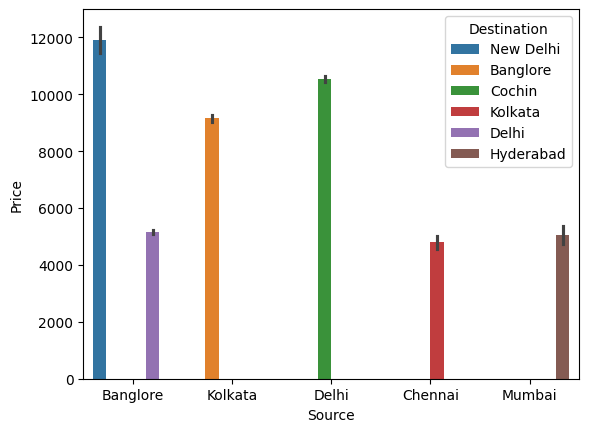

In [ ]:

# Source and Destination by price

df.groupby(['Source', 'Destination'])['Price'].mean().sort_values()
sns.barplot(x='Source', y='Price', hue='Destination', data=df)

plt.show()

## Route-Based Price Insights

- Flights from Bangalore to New Delhi tend to have the highest prices, indicating strong demand on this route.
- Chennai to Kolkata is generally the most affordable route.
- Overall, flight prices vary significantly by route, with longer distances and high-demand cities contributing to higher fares.

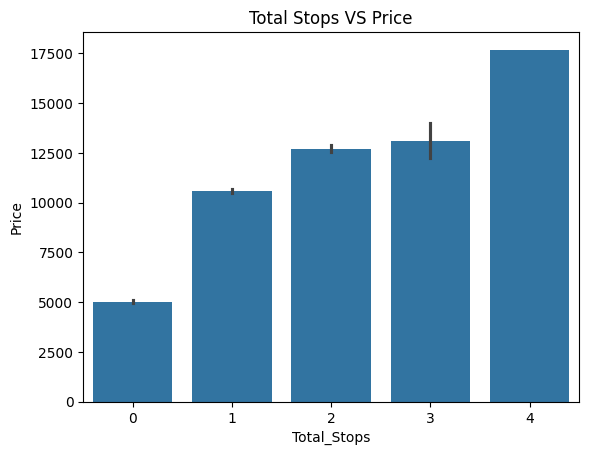

In [ ]:
sns.barplot(x="Total_Stops", y="Price", data=df)
plt.title('Total Stops VS Price')
plt.show()

## Total Stops vs Price: Key Insight

- Flight prices generally increase with the number of stops.
- Non-stop flights are the cheapest, while flights with more stops tend to be more expensive.

3. Time-Based Features

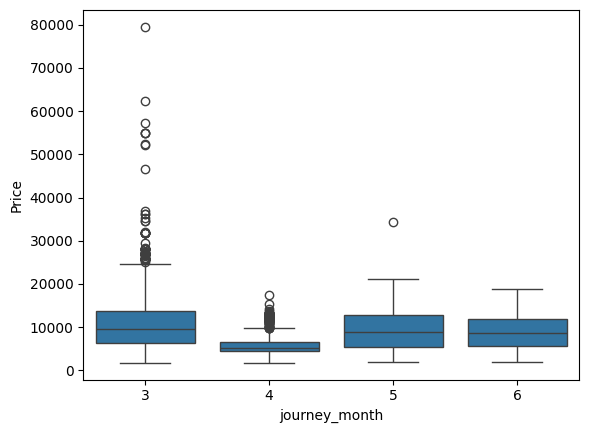

In [ ]:
sns.boxplot(x='journey_month', y = 'Price', data = df)
plt.show()


## Flight Price Variation by Journey Month: Key Insights

- **Peak Months:**  
  March, May, and June show higher prices and greater variability, indicating strong demand.

- **Off-Peak Month:**  
  April has the lowest average prices with less variation, making it more economical.

- **Seasonal Impact:**  
  Flight prices are influenced by seasonal demand, with peak travel periods leading to higher fares.

**4. Numerical vs Price**

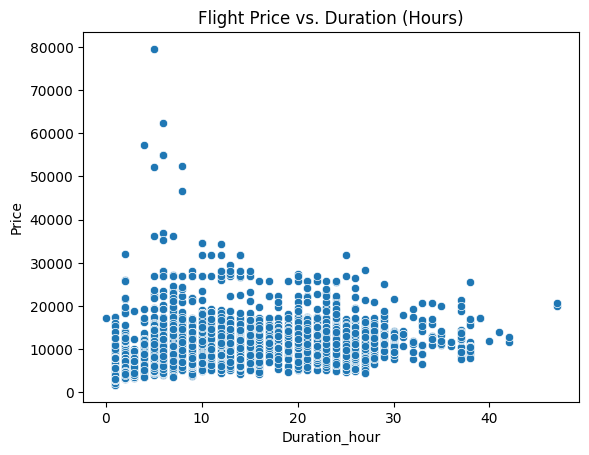

In [ ]:
sns.scatterplot(x='Duration_hour', y='Price', data=df)
plt.title('Flight Price vs. Duration (Hours)')
plt.show()

## Flight Price vs Duration: Key Insights

- There is no strong linear relationship between flight duration and price.
- Short-duration flights show a wide range of prices.
- Longer durations exhibit higher variability, but not necessarily higher prices.
- Flight price is influenced more by multiple factors such as airline, route, and number of stops rather than duration alone.

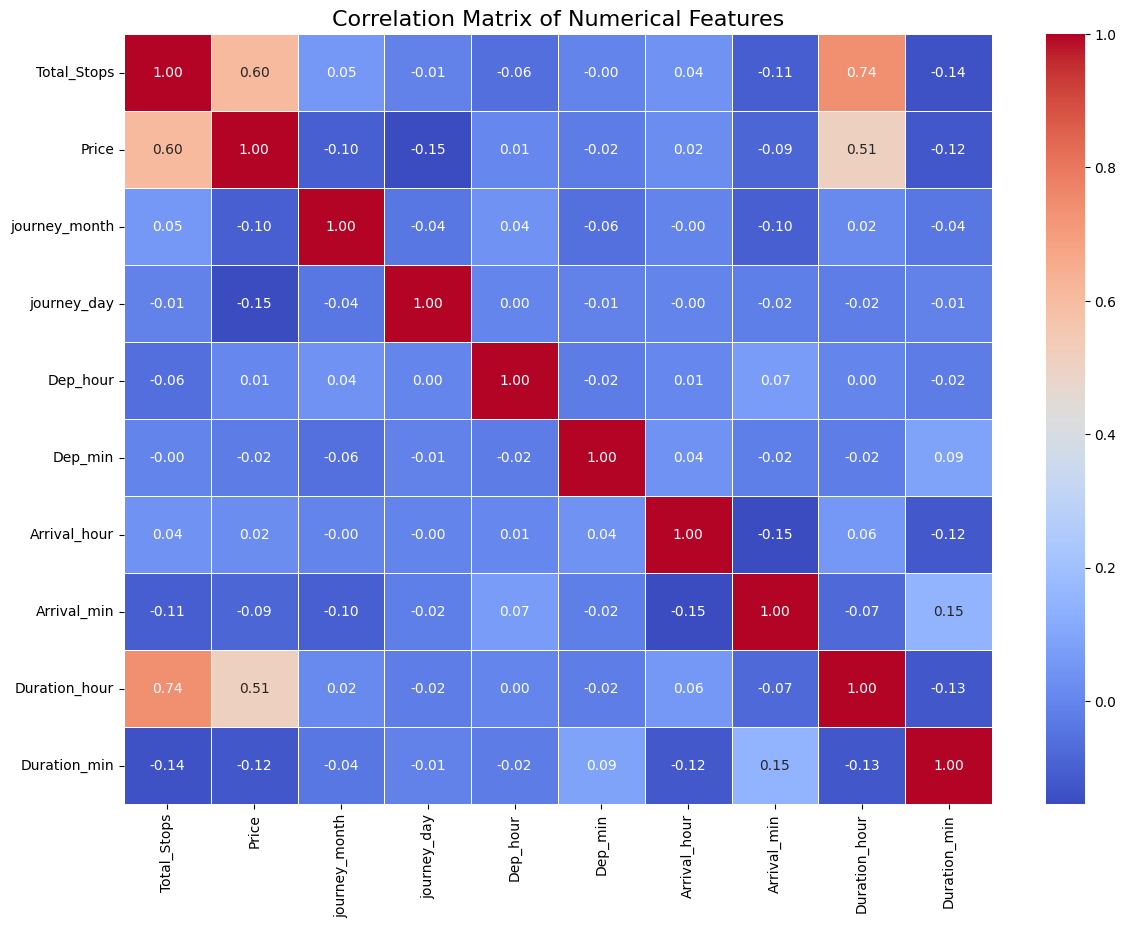

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()

## Correlation Matrix: Key Insights

- **Strong Predictors:**  
  `Total_Stops` shows the highest positive correlation with price, followed by `Duration_hour`.

- **Moderate/Weak Influence:**  
  `journey_month` has a weak positive impact, while `journey_day` shows almost no relationship with price.

- **Feature Relationships:**  
  `Duration_hour` and `Total_Stops` are positively correlated, indicating longer flights usually have more stops.

- **Low Impact Features:**  
  Other numerical features have very weak correlations and are not strong standalone predictors.


In [ ]:
df.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,journey_month,journey_day,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hour,Duration_min
0,IndiGo,Banglore,New Delhi,0,No info,3897,3,24,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2,No info,7662,5,1,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,2,No info,13882,6,9,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,1,No info,6218,5,12,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,1,No info,13302,3,1,16,50,21,35,4,45


**Data Preprocessing**


In [ ]:
X = df.drop('Price', axis=1)
y = df['Price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(include=np.number).columns

In [ ]:
cat_tranformer = OneHotEncoder(drop='first',handle_unknown="ignore")
num_transformer = StandardScaler()
# num_transformer = 'passthrough'

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_tranformer, categorical_cols),
        ('num', num_transformer, numerical_cols)
    ]
)

In [ ]:
models = {
    "Linear": LinearRegression(),
    "RandomForest": RandomForestRegressor(),
    "GradientBoosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor()
}

In [ ]:
results = []

for name, model in models.items():

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "RMSE": round(rmse, 2),
        "R2": round(r2, 4)
    })

results_df = pd.DataFrame(results)
print(results_df.sort_values(by='RMSE'))

              Model     RMSE      R2
3           XGBoost  1420.30  0.9064
1      RandomForest  1616.86  0.8788
2  GradientBoosting  1858.20  0.8399
0            Linear  2568.31  0.6941


XGBoost performed best with the lowest RMSE (1420) and highest R² (0.90), indicating strong predictive performance. The poor performance of Linear Regression suggests that the relationship between features and price is non-linear. Ensemble models like Random Forest and Gradient Boosting also performed well, but boosting-based XGBoost captured patterns more effectively.

I selected the top two performing models based on RMSE and further optimized them using hyperparameter tuning to ensure the best possible performance.

**RandomForest Tuning**

In [ ]:
rf_params = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

In [ ]:
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=rf_params,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('cat',
                                                                               OneHotEncoder(drop='first',
                                                                                             handle_unknown='ignore'),
                                                                               Index(['Airline', 'Source', 'Destination', 'Additional_Info'], dtype='object')),
                                                                              ('num',
                                                                               StandardScaler(),
                                                                               Index(['Total_Stops', 'journey_month', 'journey_day', 'Dep_hour', 'Dep_min',
       'Arrival_hour', 'Arrival_min', 'Duration_hour', 'Duration_min'],
      dtype='object'))])),
                                             ('model',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 10, 20, 30],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

In [ ]:
rf_best = rf_search.best_estimator_
print(rf_search.best_params_)

{'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 30}


In [ ]:
y_pred_rf = rf_best.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)
print("RF Tuned RMSE:", rmse)
print("RF Tuned R2:", r2)

RF Tuned RMSE: 1618.4050510034172
RF Tuned R2: 0.8785257366117564


**XGBoost Tunning**

In [ ]:
xgb_params = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}

In [ ]:
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42))
])

xgb_search = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=xgb_params,
    n_iter=20,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('cat',
                                                                               OneHotEncoder(drop='first',
                                                                                             handle_unknown='ignore'),
                                                                               Index(['Airline', 'Source', 'Destination', 'Additional_Info'], dtype='object')),
                                                                              ('num',
                                                                               StandardScaler(),
                                                                               Index(['Total_Stops', 'journey_month', 'journey_day', 'Dep_hour', 'Dep_min',
       'Arrival_hour', 'Arriv...
                                                           multi_strategy=None,
                                                           n_estimators=None,
                                                           n_jobs=None,
                                                           num_parallel_tree=None, ...))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.7, 0.8,
                                                                    1.0],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1],
                                        'model__max_depth': [3, 5, 7],
                                        'model__n_estimators': [100, 200, 300],
                                        'model__subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [ ]:
xgb_best = xgb_search.best_estimator_
print(xgb_search.best_params_)

{'model__subsample': 1.0, 'model__n_estimators': 300, 'model__max_depth': 7, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}


In [ ]:
y_pred_xgb = xgb_best.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)
print("XGB Tuned RMSE:", rmse)
print("XGB Tuned R2:", r2)

XGB Tuned RMSE: 1345.7196959248238
XGB Tuned R2: 0.9160116314888


After evaluating multiple models, XGBoost achieved the best performance with an RMSE of ~1345 and R² of ~0.91. Hyperparameter tuning further improved its performance, while Random Forest showed minimal improvement. This indicates that boosting-based models are better suited for capturing the complex, non-linear relationships in the flight price dataset.

## Project Summary: Flight Price Prediction

This project aimed to develop a machine learning model to predict flight prices using a dataset containing various flight details. The methodology involved a comprehensive data science workflow, from initial data loading and exploration to advanced model tuning.

**Key Steps and Findings:**

1.  **Data Loading & Initial Exploration:** The flight fare dataset was loaded, and initial checks revealed missing values and non-standard data types, particularly for date/time and duration features. Basic descriptive statistics and data shapes were examined.

2.  **Data Cleaning & Feature Engineering:**
    *   Missing values in 'Route' and 'Total_Stops' were handled by dropping the corresponding rows.
    *   Date and time-related columns (`Date_of_Journey`, `Dep_Time`, `Arrival_Time`) were meticulously parsed to extract numerical features such as month, day, hour, and minute.
    *   `Duration` was converted into `Duration_hour` and `Duration_min`.
    *   `Total_Stops` was mapped to numerical values, reflecting its ordinal nature.
    *   `Additional_Info` was cleaned (standardizing 'No Info' to 'No info') and rare categories were grouped into 'Other' to manage cardinality.
    *   The `Route` column was dropped due to high cardinality and redundancy with other features.

3.  **Exploratory Data Analysis (EDA):**
    *   **Price Distribution:** The target variable 'Price' showed a right-skewed distribution with a notable presence of outliers, indicating a wide range of flight costs.
    *   **Categorical vs. Price:** Analysis revealed significant price variations across airlines (e.g., Jet Airways Business being the most expensive), routes (Bangalore-New Delhi highest, Chennai-Kolkata lowest), and `Total_Stops` (prices generally increase with more stops).
    *   **Time-Based Features:** `journey_month` showed seasonal price variations, with higher prices in peak months (March, May, June).
    *   **Numerical vs. Price:** A weak linear relationship was observed between `Duration_hour` and 'Price', suggesting other factors are more influential. The correlation matrix confirmed `Total_Stops` and `Duration_hour` as the strongest numerical predictors.

4.  **Model Building & Evaluation:**
    *   The data was split into training and testing sets.
    *   A robust preprocessing pipeline was established using `ColumnTransformer` with `OneHotEncoder` for categorical features and `StandardScaler` for numerical features.
    *   Four regression models were initially evaluated: `LinearRegression`, `RandomForestRegressor`, `GradientBoostingRegressor`, and `XGBRegressor`.
    *   XGBoost emerged as the top performer with the lowest RMSE (1420.30) and highest R² (0.9064), outperforming other models significantly.

5.  **Hyperparameter Tuning:**
    *   `RandomizedSearchCV` was employed to tune the hyperparameters of the `RandomForestRegressor` and `XGBRegressor` to optimize their performance.
    *   **Random Forest Tuned:** Achieved an RMSE of 1618.41 and R² of 0.8785.
    *   **XGBoost Tuned:** Achieved an even better RMSE of 1345.72 and R² of 0.9160, solidifying its position as the best model for this task.

**Conclusion:**

The project successfully built and optimized a flight price prediction model. The XGBoost Regressor, after hyperparameter tuning, demonstrated superior predictive capability, effectively capturing the complex, non-linear relationships within the flight data. This model provides a strong foundation for predicting flight prices, offering valuable insights for travel planning and pricing strategies.